# 04 · Model training, cross-validation and tuning
Training is done by `python -m app.ml.train`. This notebook reads its saved results and re-runs one small GridSearch to show the mechanics.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
BACKEND = (Path.cwd().parent / "backend").resolve()   # notebooks/ -> backend/
sys.path.insert(0, str(BACKEND))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.config import settings
pd.set_option("display.width", 140)

In [2]:
cv = json.loads((settings.METRICS_DIR / "cv_results.json").read_text())
print(cv["cv_method"]); print(cv["selection_rule"])
rows = []
for m in cv["models"]:
    r = {"model": m["display_name"], "configs tried": m["n_configs_tried"]}
    r.update({k: f'{v["mean"]:.3f} ± {v["std"]:.3f}' for k, v in m["cv"].items()})
    rows.append(r)
pd.DataFrame(rows)

Stratified 5-fold cross-validation (shuffled, random_state=42) on the training set; tuning by GridSearchCV
Best mean CV ROC-AUC; models within 0.005 treated as tied, tie broken by lowest CV Brier score


,model,configs tried,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
0,Logistic Regression,16,0.846 ± 0.014,0.743 ± 0.051,0.759 ± 0.013,0.639 ± 0.019,0.710 ± 0.038,0.672 ± 0.022,0.166 ± 0.007
1,Decision Tree,80,0.802 ± 0.025,0.646 ± 0.030,0.705 ± 0.048,0.553 ± 0.050,0.823 ± 0.078,0.660 ± 0.054,0.181 ± 0.016
2,Random Forest,48,0.840 ± 0.021,0.739 ± 0.043,0.769 ± 0.025,0.731 ± 0.073,0.542 ± 0.020,0.621 ± 0.031,0.155 ± 0.009
3,Support Vector Machine (RBF),36,0.844 ± 0.015,0.751 ± 0.036,0.780 ± 0.017,0.730 ± 0.044,0.589 ± 0.027,0.651 ± 0.026,0.152 ± 0.007
4,Gradient Boosting,32,0.839 ± 0.018,0.751 ± 0.048,0.785 ± 0.014,0.738 ± 0.050,0.603 ± 0.043,0.661 ± 0.021,0.153 ± 0.008
5,K-Nearest Neighbours,20,0.835 ± 0.020,0.737 ± 0.040,0.759 ± 0.017,0.715 ± 0.053,0.524 ± 0.043,0.602 ± 0.028,0.158 ± 0.007
6,Soft-Voting Ensemble,1,0.847 ± 0.015,0.752 ± 0.046,0.775 ± 0.020,0.713 ± 0.055,0.603 ± 0.053,0.651 ± 0.033,0.153 ± 0.008


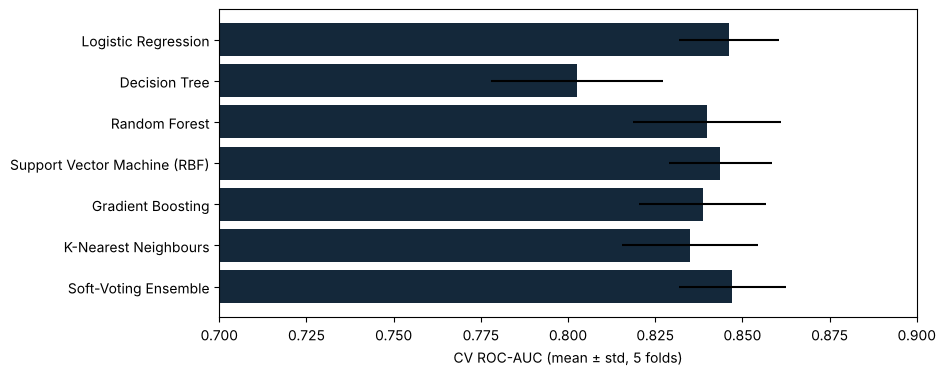

Highest mean CV ROC-AUC was 0.8471. Models within 0.005 of it (Logistic Regression, Support Vector Machine (RBF), Soft-Voting Ensemble) were treated as tied and the one with the lowest CV Brier score (0.1520) was selected: Support Vector Machine (RBF).


In [3]:
names = [m["display_name"] for m in cv["models"]]
means = [m["cv"]["roc_auc"]["mean"] for m in cv["models"]]; stds = [m["cv"]["roc_auc"]["std"] for m in cv["models"]]
plt.figure(figsize=(9, 4)); plt.barh(names, means, xerr=stds, color="#14283a"); plt.xlim(.7, .9)
plt.xlabel("CV ROC-AUC (mean ± std, 5 folds)"); plt.gca().invert_yaxis(); plt.show()
print(cv["selection_reason"])

## Best hyperparameters found

In [4]:
{m["display_name"]: m["best_params"] for m in cv["models"]}

{'Logistic Regression': {'model__C': 0.01,
  'model__class_weight': 'balanced',
  'prep__engineer__enabled': True},
 'Decision Tree': {'model__class_weight': 'balanced',
  'model__max_depth': 3,
  'model__min_samples_leaf': 20,
  'prep__engineer__enabled': False},
 'Random Forest': {'model__max_depth': 4,
  'model__max_features': 'sqrt',
  'model__min_samples_leaf': 3,
  'prep__engineer__enabled': True},
 'Support Vector Machine (RBF)': {'model__estimator__C': 1.0,
  'model__estimator__class_weight': None,
  'model__estimator__gamma': 0.01,
  'prep__engineer__enabled': True},
 'Gradient Boosting': {'model__learning_rate': 0.05,
  'model__max_depth': 2,
  'model__n_estimators': 100,
  'model__subsample': 0.8,
  'prep__engineer__enabled': False},
 'K-Nearest Neighbours': {'model__n_neighbors': 31,
  'model__weights': 'distance',
  'prep__engineer__enabled': True},
 'Soft-Voting Ensemble': {'members': ['logistic_regression',
   'svm',
   'random_forest'],
  'voting': 'soft'}}

## Mechanics demo: GridSearchCV on Logistic Regression
Same pipeline, same stratified 5-fold CV as `train.py`.

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from app.ml.data import load_dataset
from app.ml.features import CSV_COLUMNS
from app.ml.preprocessing import build_pipeline
df = load_dataset(settings.DATA_PATH)
X_train, X_test, y_train, y_test = train_test_split(df[CSV_COLUMNS], df.Outcome, test_size=.2, stratify=df.Outcome, random_state=42)
gs = GridSearchCV(build_pipeline(LogisticRegression(max_iter=2000)),
                  {"model__C": [0.01, 0.1, 1, 10], "prep__engineer__enabled": [False, True]},
                  scoring="roc_auc", cv=StratifiedKFold(5, shuffle=True, random_state=42)).fit(X_train, y_train)
print(gs.best_params_, round(gs.best_score_, 4))
pd.DataFrame(gs.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

{'model__C': 0.01, 'prep__engineer__enabled': True} 0.8454


,params,mean_test_score,std_test_score,rank_test_score
1,"{'model__C': 0.01, 'prep__engineer__enabled': ...",0.845426,0.013903,1
3,"{'model__C': 0.1, 'prep__engineer__enabled': T...",0.844452,0.018390,2
5,"{'model__C': 1, 'prep__engineer__enabled': True}",0.841242,0.022674,3
2,"{'model__C': 0.1, 'prep__engineer__enabled': F...",0.840382,0.020524,4
7,"{'model__C': 10, 'prep__engineer__enabled': True}",0.840321,0.021975,5
0,"{'model__C': 0.01, 'prep__engineer__enabled': ...",0.839693,0.013770,6
4,"{'model__C': 1, 'prep__engineer__enabled': False}",0.838515,0.023242,7
6,"{'model__C': 10, 'prep__engineer__enabled': Fa...",0.837636,0.023585,8


**Ensemble learning:** a soft-voting ensemble averages the probabilities of the top three tuned models. Its CV score is slightly optimistic because its members were tuned on the same folds; the selection rule therefore treats models within 0.005 ROC-AUC as tied and prefers the best-calibrated one (lowest Brier).